## **Exploration Notebook**
Para la gestión de costos de los diferentes insumos

In [65]:
# Manipulacion de datos
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Estadisticas
from scipy import stats
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

### **1. Exploración de datos**

In [66]:
DATA_PATH = '../data'
data_x = pd.read_csv(os.path.join(DATA_PATH, 'X.csv')) 
data_y = pd.read_csv(os.path.join(DATA_PATH, 'Y.csv')) 
data_z = pd.read_csv(os.path.join(DATA_PATH, 'Z.csv')) 

In [67]:
data_x

,Date,Price
0,2024-04-04,89.18
1,2024-04-03,89.35
2,2024-04-02,88.92
3,2024-04-01,87.42
4,2024-03-28,87.48
...,...,...
9139,1988-07-01,14.60
9140,1988-06-30,14.85
9141,1988-06-29,15.47
9142,1988-06-28,15.27


In [68]:
data_y

,Date;Price
12/9/2023;547,33.0
11/9/2023;546,NaN
8/9/2023;545,NaN
7/9/2023;550,NaN
6/9/2023;552,5.0
...,...
17/7/2006;555,NaN
14/7/2006;555,NaN
13/7/2006;555,NaN
12/7/2006;555,NaN


In [69]:
data_z

,Price,Date
0,2225.25,2010-01-01
1,2225.25,2010-01-04
2,2246.50,2010-01-05
3,2302.50,2010-01-06
4,2306.50,2010-01-07
...,...,...
3560,2123.50,2023-08-25
3561,2116.25,2023-08-28
3562,2116.25,2023-08-29
3563,2140.25,2023-08-30


> Los datasets x,y,z no son datasets usables debido a que son datos repetidos en el histórico. Además cuentan con series temporales sin registros por parte del precio del equipo para definir su relación. El único dataset completo y necesario es `historico_equipos.csv`

In [70]:
data_historico = pd.read_csv(os.path.join(DATA_PATH, 'historico_equipos.csv'), parse_dates=['Date'])
# Revisemos rango de fechas completo
print(f"Rango:\n{data_historico['Date'].min()} - {data_historico['Date'].max()}")
# Revisemos si hay datos faltantes
print(f"Datos faltantes:\n{data_historico.isnull().sum()}")
# Revisemos si hay datos duplicados
print(f"Datos duplicados:\n{data_historico.duplicated().sum()}")

Rango:
2010-01-04 00:00:00 - 2023-08-31 00:00:00
Datos faltantes:
Date             0
Price_X          0
Price_Y          0
Price_Z          0
Price_Equipo1    0
Price_Equipo2    0
dtype: int64
Datos duplicados:
0


> No vemos datos duplicados por fecha o registro, tampoco datos faltantes en los features

In [71]:
data_historico

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.50,2225.25,434.73,931.73
1,2010-01-05,80.59,527.50,2246.50,449.97,968.56
2,2010-01-06,81.89,527.50,2302.50,444.48,960.51
3,2010-01-07,81.51,527.50,2306.50,440.90,960.14
4,2010-01-08,81.37,552.50,2261.25,448.82,949.55
...,...,...,...,...,...,...
3525,2023-08-25,84.48,554.00,2123.50,450.36,899.65
3526,2023-08-28,84.42,549.00,2116.25,469.03,933.20
3527,2023-08-29,85.49,545.33,2116.25,460.42,901.79
3528,2023-08-30,85.86,543.67,2140.25,464.80,945.40


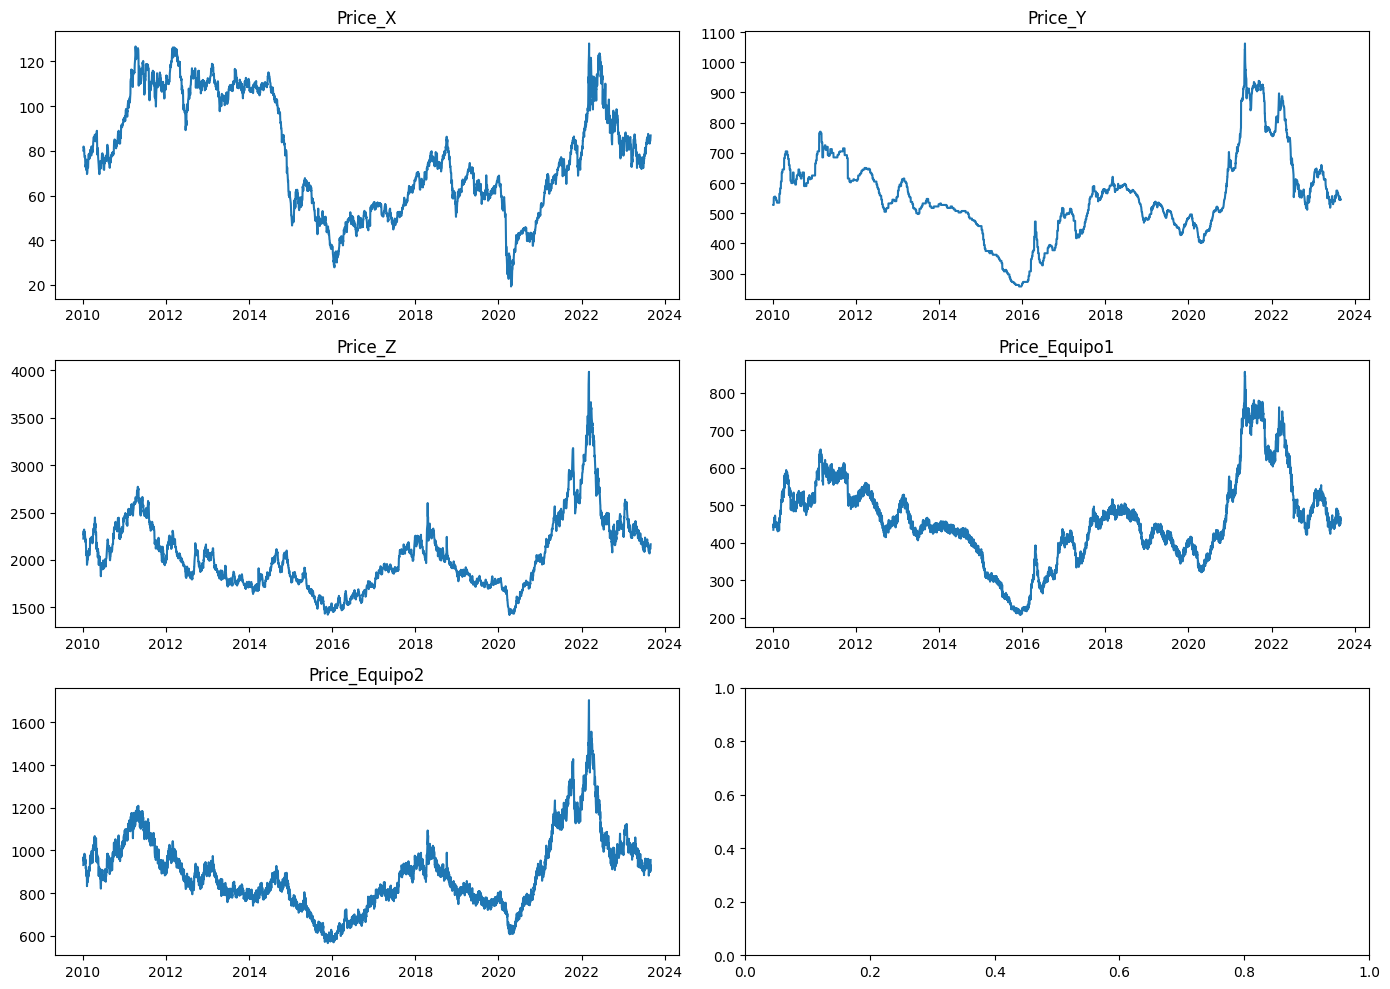

In [72]:
# Series de tiempo
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
cols = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']
for i, col in enumerate(cols):
    ax = axes[i // 2][i % 2]
    ax.plot(data_historico['Date'], data_historico[col])
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('outputs/series_tiempo.png', dpi=120)
plt.show()

In [73]:
# Detección de outliers con IQR
for col in cols:
    Q1, Q3 = data_historico[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((data_historico[col] < Q1 - 1.5*IQR) | (data_historico[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {n_out} outliers")

Price_X: 0 outliers
Price_Y: 291 outliers
Price_Z: 90 outliers
Price_Equipo1: 223 outliers
Price_Equipo2: 105 outliers


> Según el IQR tenemos outliers, pero son realmente outliers que debemos eliminar?

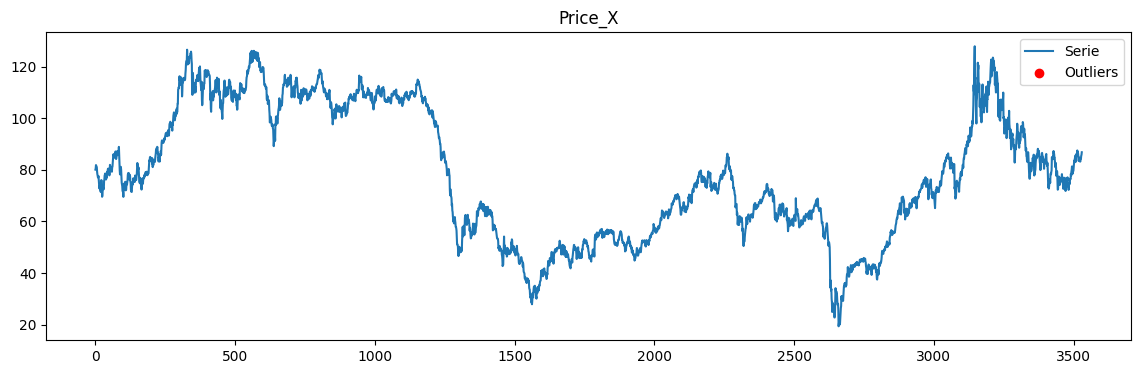

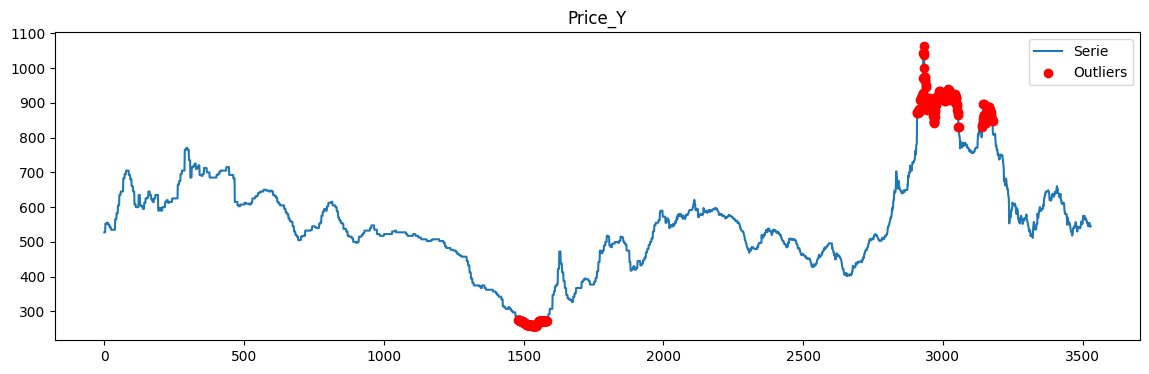

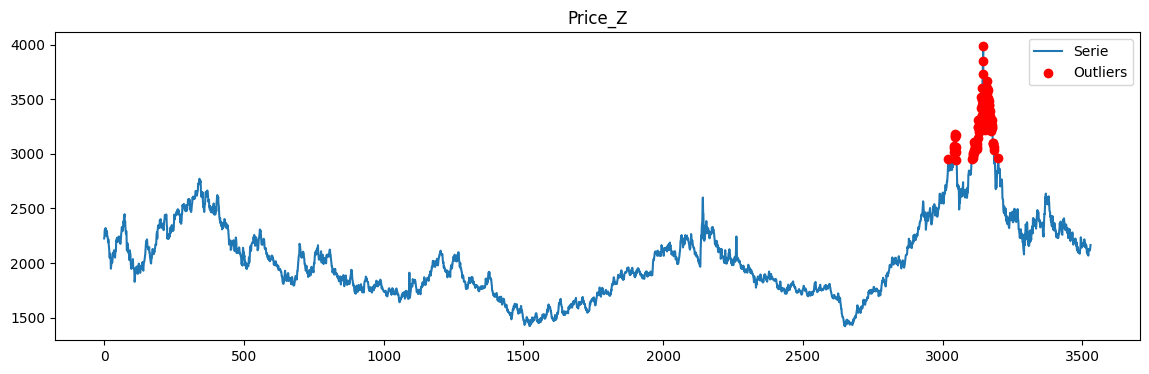

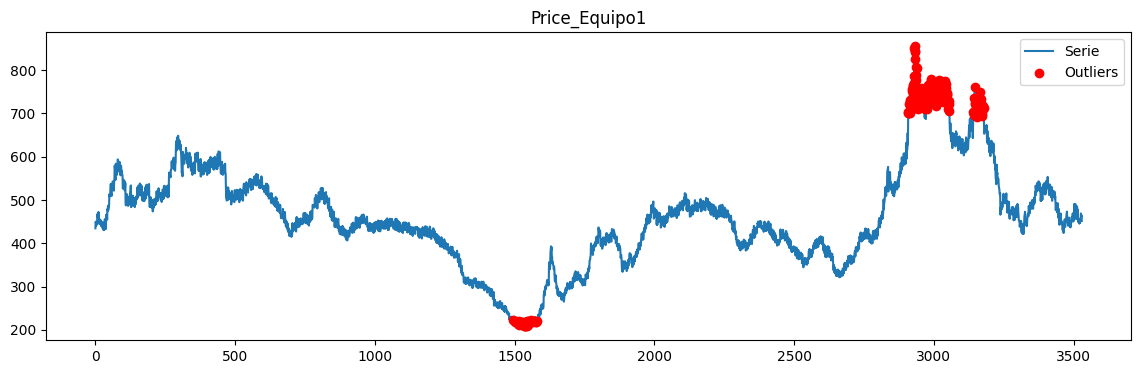

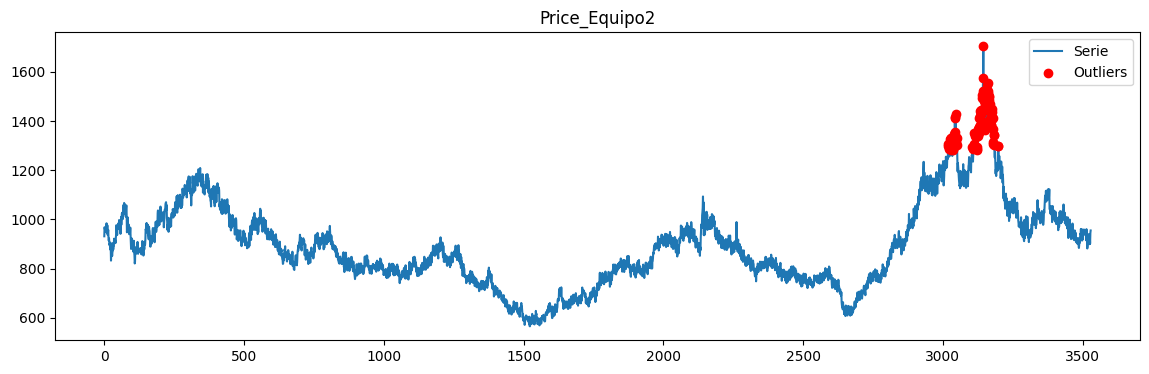

In [74]:
for col in cols:
    Q1, Q3 = data_historico[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    mask = (data_historico[col] < Q1 - 1.5*IQR) | (data_historico[col] > Q3 + 1.5*IQR)
    
    plt.figure(figsize=(14, 4))
    plt.plot(data_historico.index, data_historico[col], label='Serie')
    plt.scatter(data_historico.index[mask], data_historico[col][mask], 
                color='red', label='Outliers', zorder=5)
    plt.title(col)
    plt.legend()
    plt.savefig(f'outputs/outliers_{col}.png', dpi=120)
    plt.show()

In [75]:
# Los outliers duran 1 dato o varios consecutivos?
for col in cols:
    Q1, Q3 = data_historico[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    mask = (data_historico[col] < Q1 - 1.5*IQR) | (data_historico[col] > Q3 + 1.5*IQR)
    
    # Racha máxima consecutiva de outliers
    from itertools import groupby
    streaks = [sum(1 for _ in g) for k, g in groupby(mask) if k]
    print(f"{col}: racha máxima = {max(streaks) if streaks else 0} días consecutivos")

Price_X: racha máxima = 0 días consecutivos
Price_Y: racha máxima = 150 días consecutivos
Price_Z: racha máxima = 78 días consecutivos
Price_Equipo1: racha máxima = 84 días consecutivos
Price_Equipo2: racha máxima = 64 días consecutivos


> Esto quiere decir que es un tema estacional o temporal según las condiciones de mercado, no es necesario imputar dichos outliers.

#### **1.1. Relaciones entre variables**

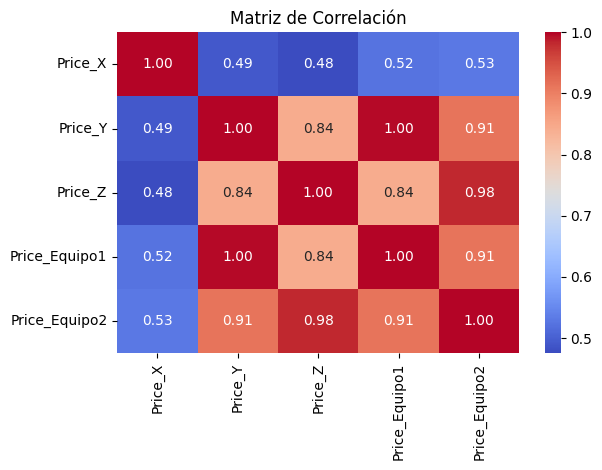

In [76]:
corr = data_historico[['Price_X','Price_Y','Price_Z','Price_Equipo1','Price_Equipo2']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

In [77]:
# Correlaciones con rezagos
equipos = ['Price_Equipo1', 'Price_Equipo2']
materias = ['Price_X', 'Price_Y', 'Price_Z']

lag_results = []
for eq in equipos:
    for mp in materias:
        for lag in range(0, 7):
            r, p = stats.pearsonr(
                data_historico[mp].iloc[lag:],
                data_historico[eq].iloc[lag:].values  
            )
            # Versión correcta con shift:
            shifted = data_historico[mp].shift(lag)
            mask = shifted.notna()
            r2, p2 = stats.pearsonr(shifted[mask], data_historico[eq][mask])
            lag_results.append({'equipo': eq, 'materia': mp, 'lag': lag, 'r': r2, 'p': p2})

lag_df = pd.DataFrame(lag_results)
# Muestra el lag con mayor correlación por combinación
print(lag_df.sort_values('r', ascending=False).groupby(['equipo','materia']).first())

                       lag         r              p
equipo        materia                              
Price_Equipo1 Price_X    0  0.523371  1.542633e-247
              Price_Y    0  0.996618   0.000000e+00
              Price_Z    1  0.844033   0.000000e+00
Price_Equipo2 Price_X    0  0.530345  2.450389e-255
              Price_Y    0  0.912702   0.000000e+00
              Price_Z    0  0.982675   0.000000e+00


> Aparentemente solo encontramos un rezago a nivel diario con el insumo Y, y todas nuestras variables tienen p-values muy pequeños lo que nos dice que no existen valores con ruido 

#### **1.2. Testing**

In [78]:
for col in ['Price_X','Price_Y','Price_Z','Price_Equipo1','Price_Equipo2']:
    adf_stat, p_val, _, _, _, _ = adfuller(df_m[col].dropna())
    estacionaria = 'SÍ' if p_val < 0.05 else 'NO'
    print(f"{col}: ADF={adf_stat:.3f}, p={p_val:.4f}. Estacionariedad? {estacionaria}")

Price_X: ADF=-1.754, p=0.4036. Estacionariedad? NO
Price_Y: ADF=-1.962, p=0.3036. Estacionariedad? NO
Price_Z: ADF=-2.923, p=0.0428. Estacionariedad? SÍ
Price_Equipo1: ADF=-1.938, p=0.3143. Estacionariedad? NO
Price_Equipo2: ADF=-3.067, p=0.0291. Estacionariedad? SÍ


In [79]:
df_diff = data_historico[['Price_X','Price_Y','Price_Z','Price_Equipo1','Price_Equipo2']].diff().dropna()
print(df_diff.corr()[['Price_Equipo1','Price_Equipo2']].round(3))

               Price_Equipo1  Price_Equipo2
Price_X                0.048          0.085
Price_Y                0.386          0.128
Price_Z                0.024          0.431
Price_Equipo1          1.000          0.058
Price_Equipo2          0.058          1.000


In [80]:
from statsmodels.tsa.stattools import coint

for mp in ['Price_X', 'Price_Y', 'Price_Z']:
    for eq in ['Price_Equipo1', 'Price_Equipo2']:
        stat, p, _ = coint(data_historico[mp], data_historico[eq])
        print(f"{mp} → {eq}: p={p:.4f} {'✓ Cointegradas' if p < 0.05 else '✗'}")

Price_X → Price_Equipo1: p=0.4996 ✗
Price_X → Price_Equipo2: p=0.5747 ✗
Price_Y → Price_Equipo1: p=0.0130 ✓ Cointegradas
Price_Y → Price_Equipo2: p=0.0026 ✓ Cointegradas
Price_Z → Price_Equipo1: p=0.0059 ✓ Cointegradas
Price_Z → Price_Equipo2: p=0.0084 ✓ Cointegradas


In [81]:
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

def fit_ecm(y, x, name=""):
    # 1. Relación de largo plazo
    reg_lp = sm.OLS(y, sm.add_constant(x)).fit()
    equilibrio = reg_lp.resid  # término de corrección de error

    # 2. Ecuación en diferencias + término de corrección
    dy = y.diff().dropna()
    dx = x.diff().dropna()
    ec_lag = equilibrio.shift(1).dropna()

    # Alinear índices
    idx = dy.index.intersection(dx.index).intersection(ec_lag.index)
    X_ecm = sm.add_constant(pd.DataFrame({'dx': dx[idx], 'ec_lag': ec_lag[idx]}))
    model = sm.OLS(dy[idx], X_ecm).fit()

    print(f"\n=== ECM {name} ===")
    print(f"R² largo plazo: {reg_lp.rsquared:.4f}")
    print(f"R² ECM:         {model.rsquared:.4f}")
    print(model.summary().tables[1])
    return reg_lp, model

# Ejecutar — usa Y o Z según cuál tenga mejor fit, o prueba ambas
lp1_z, ecm1_z = fit_ecm(data_historico['Price_Equipo1'], data_historico['Price_Z'], 'Equipo1~Z')
lp2_z, ecm2_z = fit_ecm(data_historico['Price_Equipo2'], data_historico['Price_Z'], 'Equipo2~Z')


=== ECM Equipo1~Z ===
R² largo plazo: 0.7124
R² ECM:         0.0115
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0053      0.210      0.025      0.980      -0.407       0.417
dx             0.0122      0.007      1.810      0.070      -0.001       0.025
ec_lag        -0.0216      0.003     -6.251      0.000      -0.028      -0.015

=== ECM Equipo2~Z ===
R² largo plazo: 0.9656
R² ECM:         0.2904
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0121      0.353      0.034      0.973      -0.679       0.704
dx             0.3533      0.011     31.188      0.000       0.331       0.375
ec_lag        -0.2555      0.011    -22.816      0.000      -0.277      -0.234


In [82]:
# Prueba Y solo
lp1_y, ecm1_y = fit_ecm(data_historico['Price_Equipo1'], data_historico['Price_Y'], 'Equipo1~Y')

# Luego prueba multivariado Y+Z para Equipo1
def fit_ecm_multi(y, X_df, name=""):
    reg_lp = sm.OLS(y, sm.add_constant(X_df)).fit()
    equilibrio = reg_lp.resid

    dy = y.diff().dropna()
    dX = X_df.diff().dropna()
    ec_lag = equilibrio.shift(1).dropna()

    idx = dy.index.intersection(dX.index).intersection(ec_lag.index)
    X_ecm = sm.add_constant(dX.loc[idx].assign(ec_lag=ec_lag[idx]))
    model = sm.OLS(dy[idx], X_ecm).fit()

    print(f"\n=== ECM {name} ===")
    print(f"R² largo plazo: {reg_lp.rsquared:.4f}")
    print(f"R² ECM:         {model.rsquared:.4f}")
    print(model.summary().tables[1])
    return reg_lp, model

fit_ecm_multi(
    data_historico['Price_Equipo1'],
    data_historico[['Price_Y', 'Price_Z']],
    'Equipo1~Y+Z'
)


=== ECM Equipo1~Y ===
R² largo plazo: 0.9932
R² ECM:         0.4770
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.153      0.007      0.995      -0.299       0.301
dx             0.7504      0.025     30.082      0.000       0.701       0.799
ec_lag        -0.7706      0.016    -47.052      0.000      -0.803      -0.738

=== ECM Equipo1~Y+Z ===
R² largo plazo: 0.9933
R² ECM:         0.4782
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.153      0.007      0.994      -0.298       0.301
Price_Y        0.7493      0.025     29.826      0.000       0.700       0.799
Price_Z       -0.0021      0.005     -0.423      0.672      -0.012       0.008
ec_lag        -0.7732      0.016    -47.143      0.000      -0.805    

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x13518c230>,
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x13518e3f0>)

#### **Modelado**

Train: 2010-01-04 00:00:00 → 2020-12-07 00:00:00 (2824 días)
Test:  2020-12-08 00:00:00 → 2023-08-31 00:00:00 (706 días)

=== Equipo1~Y — Desempeño out-of-sample ===
  MAE:  10.17
  RMSE: 163.92
  MAPE: 1.72%
  R²:   0.9866


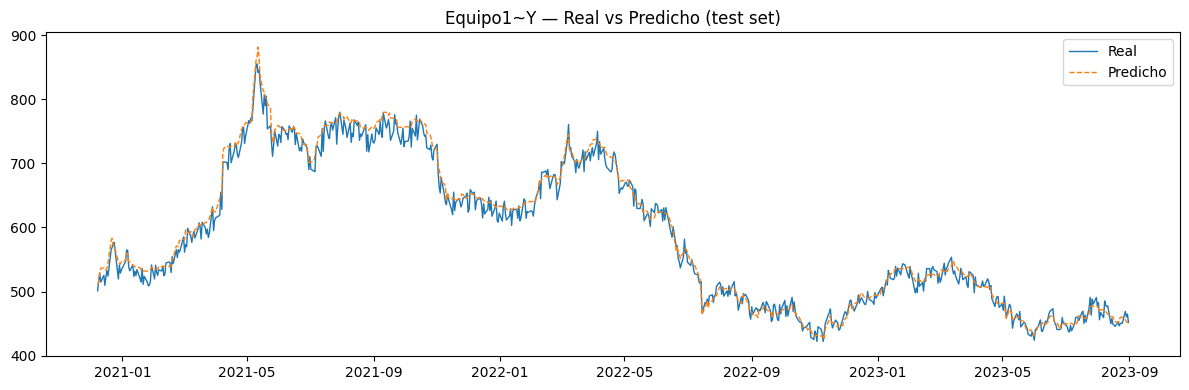


=== Equipo2~Z — Desempeño out-of-sample ===
  MAE:  36.20
  RMSE: 1978.45
  MAPE: 3.24%
  R²:   0.9220


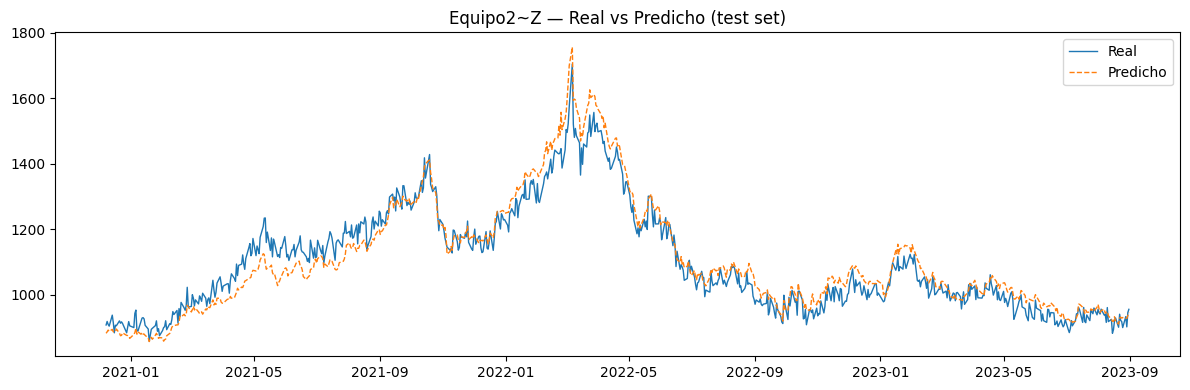

In [83]:
# ── Train/Test Split Temporal ──────────────────────────────────────────────
# 80% train, 20% test — nunca aleatorio en series de tiempo
split = int(len(data_historico) * 0.8)
train = data_historico.iloc[:split].copy()
test  = data_historico.iloc[split:].copy()

print(f"Train: {train['Date'].min()} → {train['Date'].max()} ({len(train)} días)")
print(f"Test:  {test['Date'].min()} → {test['Date'].max()} ({len(test)} días)")

# ── Función ECM con evaluación out-of-sample ───────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def fit_eval_ecm(train, test, y_col, x_col, name=""):
    # 1. Relación de largo plazo (estimada SOLO en train)
    reg_lp = sm.OLS(train[y_col], sm.add_constant(train[x_col])).fit()

    # 2. Término de corrección de error en train
    ec_train = reg_lp.resid

    # 3. Construir X del ECM en train
    dy_train  = train[y_col].diff().dropna()
    dx_train  = train[x_col].diff().dropna()
    ec_lag_tr = ec_train.shift(1).dropna()
    idx_tr    = dy_train.index.intersection(dx_train.index).intersection(ec_lag_tr.index)

    X_ecm_train = sm.add_constant(pd.DataFrame({
        'dx':     dx_train[idx_tr],
        'ec_lag': ec_lag_tr[idx_tr]
    }))
    ecm_model = sm.OLS(dy_train[idx_tr], X_ecm_train).fit()

    # 4. Predicción out-of-sample en test
    # El ECM predice Δy; acumulamos sobre el último valor conocido de train
    last_y   = train[y_col].iloc[-1]
    last_ec  = ec_train.iloc[-1]   # desequilibrio al final del train

    preds = []
    y_prev  = last_y
    ec_prev = last_ec

    for i in range(len(test)):
        dx_i  = test[x_col].iloc[i] - (test[x_col].iloc[i-1] if i > 0 else train[x_col].iloc[-1])
        dy_hat = (ecm_model.params['const'] +
                  ecm_model.params['dx']     * dx_i +
                  ecm_model.params['ec_lag'] * ec_prev)

        y_hat   = y_prev + dy_hat
        preds.append(y_hat)

        # Actualizar estado para siguiente paso
        y_prev  = y_hat
        ec_prev = y_hat - (reg_lp.params['const'] + reg_lp.params[x_col] * test[x_col].iloc[i])

    test = test.copy()
    test['pred'] = preds
    y_true = test[y_col].values

    mae  = mean_absolute_error(y_true, preds)
    rmse = mean_squared_error(y_true, preds)
    r2   = r2_score(y_true, preds)
    mape = (abs((y_true - preds) / y_true)).mean() * 100

    print(f"\n=== {name} — Desempeño out-of-sample ===")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²:   {r2:.4f}")

    # Plot real vs predicho
    plt.figure(figsize=(12, 4))
    plt.plot(test['Date'], y_true, label='Real',     linewidth=1)
    plt.plot(test['Date'], preds,  label='Predicho', linewidth=1, linestyle='--')
    plt.title(f'{name} — Real vs Predicho (test set)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'outputs/test_{name}.png', dpi=120)
    plt.show()

    return reg_lp, ecm_model, test

# ── Ejecutar ───────────────────────────────────────────────────────────────
lp1, ecm1, test_eq1 = fit_eval_ecm(train, test, 'Price_Equipo1', 'Price_Y', 'Equipo1~Y')
lp2, ecm2, test_eq2 = fit_eval_ecm(train, test, 'Price_Equipo2', 'Price_Z', 'Equipo2~Z')

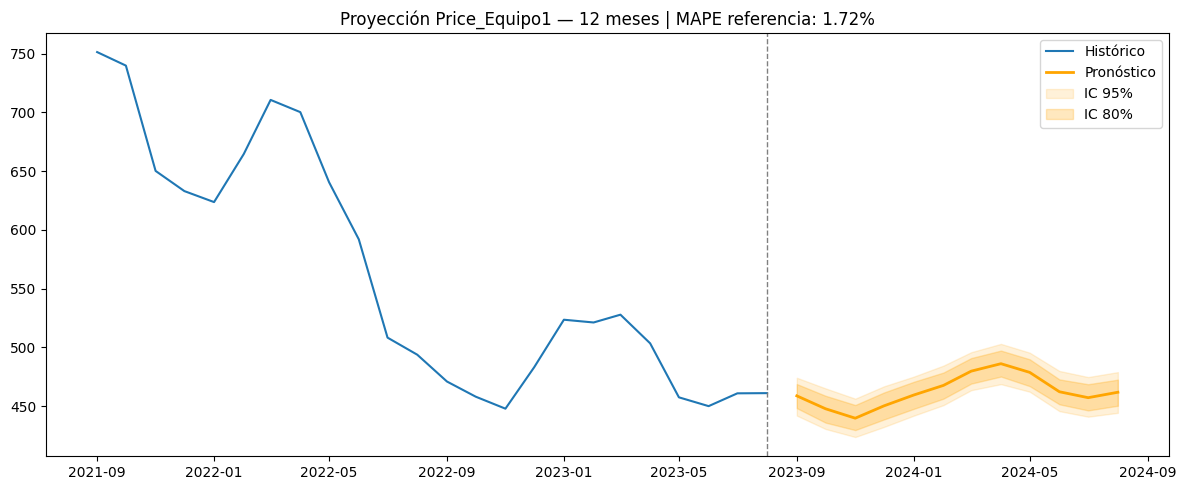

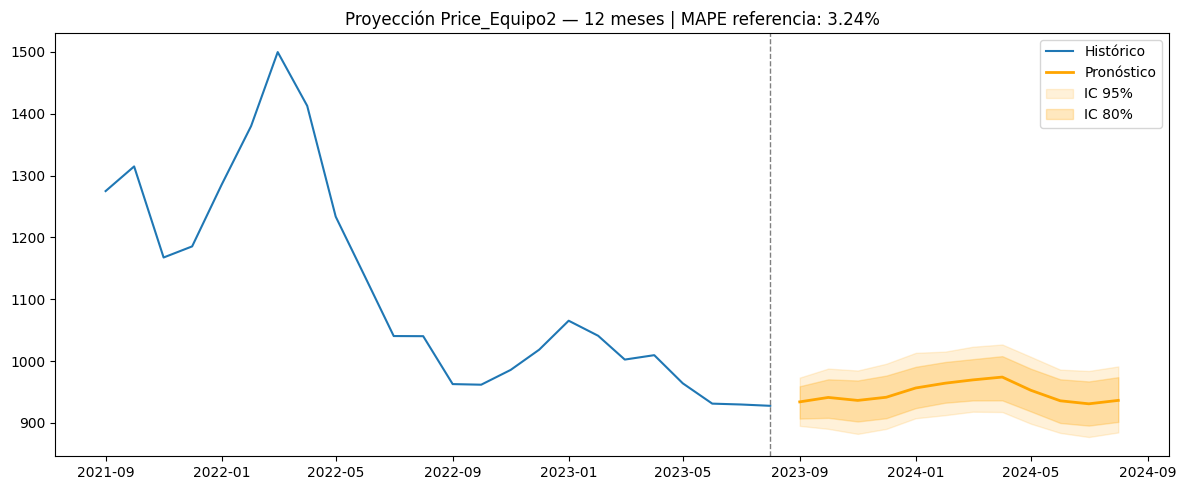

      Date        equipo materia  pred_mean   lower_80    upper_80   lower_95    upper_95
2023-09-01 Price_Equipo1 Price_Y 458.734837 448.277333  468.749566 441.942795  474.130270
2023-10-01 Price_Equipo1 Price_Y 447.733514 435.935509  458.788169 430.529473  465.074079
2023-11-01 Price_Equipo1 Price_Y 439.710617 429.594005  450.926719 423.687740  456.331415
2023-12-01 Price_Equipo1 Price_Y 450.227332 438.639804  461.595023 432.268590  466.834442
2024-01-01 Price_Equipo1 Price_Y 459.422498 447.634396  470.662084 441.846119  475.066866
2024-02-01 Price_Equipo1 Price_Y 467.617317 456.325855  478.547713 450.815889  484.449949
2024-03-01 Price_Equipo1 Price_Y 479.751973 469.153569  490.882680 463.535752  495.864254
2024-04-01 Price_Equipo1 Price_Y 486.082099 475.139100  497.229403 468.666670  502.945135
2024-05-01 Price_Equipo1 Price_Y 478.700552 466.997583  489.837307 462.245838  495.458640
2024-06-01 Price_Equipo1 Price_Y 462.209810 451.519896  472.717685 445.708095  479.906952
2024-07-01

In [84]:
# ── FASE 4: Proyección ─────────────────────────────────────────────────────
HORIZON = 12  # meses — ajusta según ventana del proyecto

# Resamplear a mensual para proyectar (más interpretable que proyectar día a día)
data_m = data_historico.set_index('Date').resample('MS').mean().reset_index()

def proyectar_ecm(data_m, y_col, x_col, lp_model, ecm_model, horizon=12, n_sim=1000):
    """
    Proyecta 'horizon' meses hacia adelante usando el ECM.
    Propaga incertidumbre via simulación bootstrap de los residuales.
    """
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

    serie_x = data_m.set_index('Date')[x_col]

    # 1. Proyectar la materia prima con Holt-Winters
    hw = ExponentialSmoothing(
        serie_x, trend='add', seasonal='add', seasonal_periods=12
    ).fit()
    x_forecast = hw.forecast(horizon)

    future_dates = pd.date_range(
        start=data_m['Date'].max() + pd.DateOffset(months=1),
        periods=horizon, freq='MS'
    )

    # 2. Proyección puntual del equipo via ECM acumulado
    last_y  = data_m[y_col].iloc[-1]
    last_x  = data_m[x_col].iloc[-1]
    last_ec = last_y - (lp_model.params['const'] + lp_model.params[x_col] * last_x)

    preds_mean = []
    y_prev, x_prev, ec_prev = last_y, last_x, last_ec

    for x_i in x_forecast:
        dx_i   = x_i - x_prev
        dy_hat = (ecm_model.params['const'] +
                  ecm_model.params['dx']     * dx_i +
                  ecm_model.params['ec_lag'] * ec_prev)
        y_hat  = y_prev + dy_hat
        preds_mean.append(y_hat)
        ec_prev = y_hat - (lp_model.params['const'] + lp_model.params[x_col] * x_i)
        y_prev, x_prev = y_hat, x_i

    # 3. Intervalos de confianza via bootstrap de residuales del ECM
    resid_std = ecm_model.resid.std()
    sims = []
    for _ in range(n_sim):
        y_s, x_s, ec_s = last_y, last_x, last_ec
        trayectoria = []
        for x_i in x_forecast:
            dx_i   = x_i - x_s
            noise  = np.random.normal(0, resid_std)
            dy_hat = (ecm_model.params['const'] +
                      ecm_model.params['dx']     * dx_i +
                      ecm_model.params['ec_lag'] * ec_s + noise)
            y_s   = y_s + dy_hat
            trayectoria.append(y_s)
            ec_s  = y_s - (lp_model.params['const'] + lp_model.params[x_col] * x_i)
            x_s   = x_i
        sims.append(trayectoria)

    sims     = np.array(sims)
    lower_95 = np.percentile(sims, 2.5,  axis=0)
    upper_95 = np.percentile(sims, 97.5, axis=0)
    lower_80 = np.percentile(sims, 10,   axis=0)
    upper_80 = np.percentile(sims, 90,   axis=0)

    # 4. DataFrame resultado
    df_proj = pd.DataFrame({
        'Date':      future_dates,
        'equipo':    y_col,
        'materia':   x_col,
        'pred_mean': preds_mean,
        'lower_80':  lower_80,
        'upper_80':  upper_80,
        'lower_95':  lower_95,
        'upper_95':  upper_95,
    })

    # 5. Plot
    hist = data_m.set_index('Date')[y_col].iloc[-24:]
    plt.figure(figsize=(12, 5))
    plt.plot(hist, label='Histórico', linewidth=1.5)
    plt.plot(future_dates, preds_mean, label='Pronóstico', color='orange', linewidth=2)
    plt.fill_between(future_dates, lower_95, upper_95, alpha=0.15, color='orange', label='IC 95%')
    plt.fill_between(future_dates, lower_80, upper_80, alpha=0.25, color='orange', label='IC 80%')
    plt.axvline(data_m['Date'].max(), color='gray', linestyle='--', linewidth=1)
    plt.title(f'Proyección {y_col} — {horizon} meses | MAPE referencia: {"1.72%" if "Equipo1" in y_col else "3.24%"}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'outputs/proyeccion_{y_col}.png', dpi=120)
    plt.show()

    return df_proj

# ── Ejecutar ───────────────────────────────────────────────────────────────
proj1 = proyectar_ecm(data_m, 'Price_Equipo1', 'Price_Y', lp1, ecm1, horizon=HORIZON)
proj2 = proyectar_ecm(data_m, 'Price_Equipo2', 'Price_Z', lp2, ecm2, horizon=HORIZON)

# Exportar
df_final = pd.concat([proj1, proj2])
df_final.to_csv('outputs/proyeccion_equipos.csv', index=False)
print(df_final.to_string(index=False))